In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

In [3]:
import seaborn as sns

In [4]:
df = pd.read_csv("netflix_titles.csv")

In [33]:
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,No especificado,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Desconocido,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",No especificado,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Desconocido,No especificado,No especificado,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Desconocido,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,Desconocido,No especificado,No especificado,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [6]:
#Carga y exploración del dataset (Capa Data)
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [7]:
df.shape

(8807, 12)

In [8]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

In [9]:
df.dtypes

show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object

In [10]:
#Limpieza de los datos
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [11]:
(df.isnull().sum() / len(df)) * 100

show_id          0.000000
type             0.000000
title            0.000000
director        29.908028
cast             9.367549
country          9.435676
date_added       0.113546
release_year     0.000000
rating           0.045418
duration         0.034064
listed_in        0.000000
description      0.000000
dtype: float64

In [12]:
df.duplicated().sum()

np.int64(0)

In [18]:
#Remplazamos los valores faltantes en la columna director por desconocido
df['director'] = df['director'].fillna('Desconocido')

In [17]:
#Remplazamos los valores faltantes en la columna cast por no especificado
df['cast'] = df['cast'].fillna('No especificado')

In [19]:
#Remplazamos los valores faltantes en la columna country por no especificado
df['country'] = df['country'].fillna('No especificado')

In [20]:
#Se eliminaron los registros sin fecha de agregado ya que representan un porcentaje mínimo
df = df.dropna(subset=['date_added'])

In [21]:
#Los valores faltantes en rating fueron reemplazados por la moda
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])

In [22]:
#Se reemplazaron los valores faltantes en duration utilizando la moda
df['duration'] = df['duration'].fillna(df['duration'].mode()[0])

In [23]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [24]:
#Durante la etapa de limpieza se trataron valores nulos mediante reemplazo y eliminación dependiendo de la importancia de cada columna y 
#el porcentaje de datos faltantes.

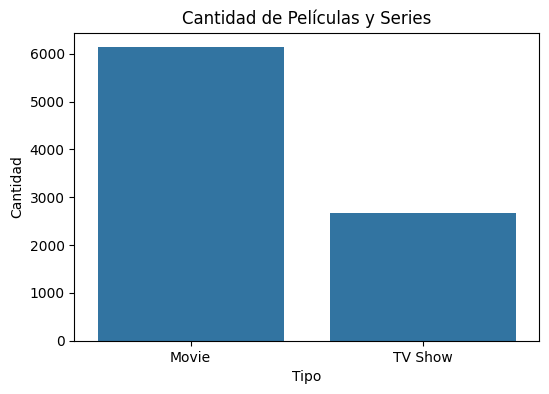

In [32]:
#Analisis descriptivo (Capa de Información)
#Graficamos qué tipo de contenido predomina más
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='type')
plt.title("Cantidad de Películas y Series")
plt.xlabel("Tipo")
plt.ylabel("Cantidad")
plt.show()

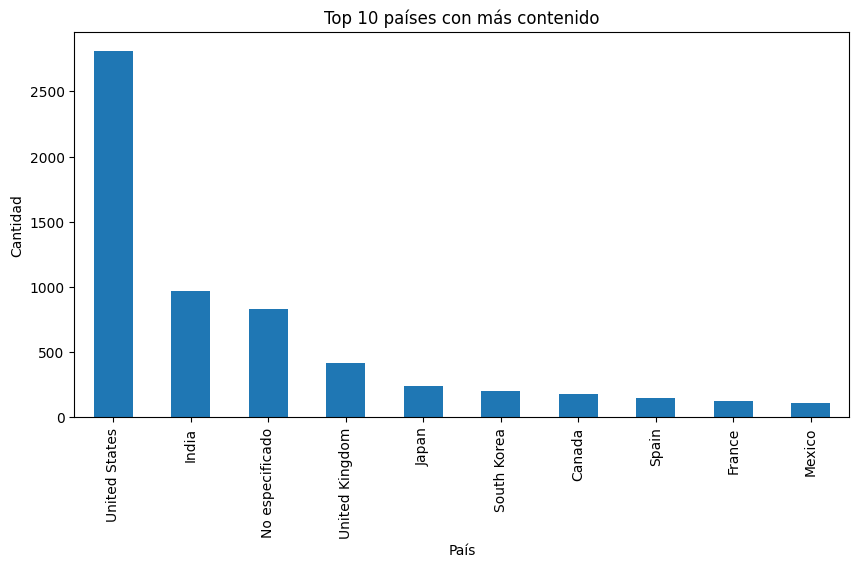

In [26]:
#Graficamos los países con mayor contenido en Netflix
top_paises = df['country'].value_counts().head(10)
plt.figure(figsize=(10,5))
top_paises.plot(kind='bar')
plt.title("Top 10 países con más contenido")
plt.xlabel("País")
plt.ylabel("Cantidad")
plt.show()

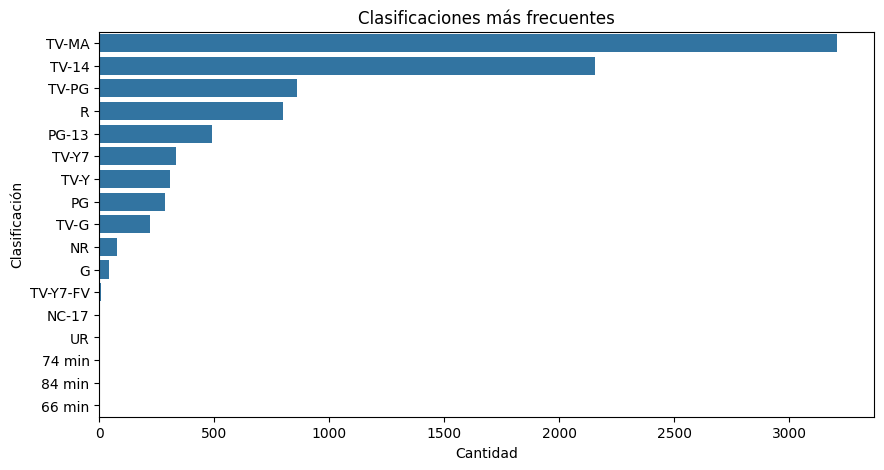

In [31]:
#Graficamos que clasificaciones de contenido son más comunes
plt.figure(figsize=(10,5))
sns.countplot(data=df, y='rating', order=df['rating'].value_counts().index)
plt.title("Clasificaciones más frecuentes")
plt.xlabel("Cantidad")
plt.ylabel("Clasificación")
plt.show()

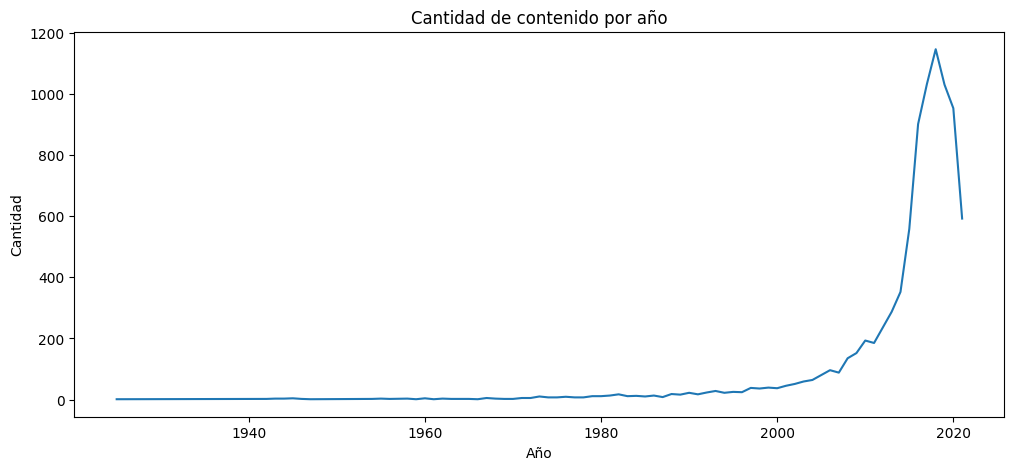

In [28]:
#Graficamos el contenido agregado a lo largo de los años
plt.figure(figsize=(12,5))
df['release_year'].value_counts().sort_index().plot()
plt.title("Cantidad de contenido por año")
plt.xlabel("Año")
plt.ylabel("Cantidad")
plt.show()

In [30]:
#Interpretación de patrones (Capa de conocimiento)
#Conclusión 1 
#El análisis muestra que Netflix cuenta con una mayor cantidad de películas en comparación con series.

#Conclusión 2
#Estados Unidos aparece como el país con más contenido dentro del dataset, lo que refleja su gran influencia en la industria del 
#entretenimiento.

#Conclusión 3
#Se observó un incremento significativo en la cantidad de contenido lanzado después del año 2000, lo que demuestra el crecimiento y 
#expansión de la plataforma durante los últimos años.